# Patient Records — Descriptive EDA

Exploratory analysis on the cleaned dataset to inform missing-data masking strategy.

**Source:** `../backend/app/data/patient_records_clean.csv`  
**Kernel:** `.venv (Python 3.12)` under `missing-data-pipeline/backend`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../backend/app/data/patient_records_clean.csv")
FINDINGS_PATH = Path("../backend/app/data/eda_findings.md")

df = pd.read_csv(DATA_PATH)

numeric_cols = ["age", "bmi", "systolic_bp", "glucose", "visits_last_year", "severity_score"]
categorical_cols = ["gender", "smoking_status", "region"]
id_col = "patient_id"

print(f"Loaded {len(df):,} rows × {len(df.columns)} columns from {DATA_PATH.resolve()}")
print(f"Missing values: {df.isna().sum().sum()}")
df.head()

Loaded 382 rows × 10 columns from C:\Users\amalj\OneDrive\Desktop\dissertation\missing-data-pipeline\backend\app\data\patient_records_clean.csv
Missing values: 0


,patient_id,age,gender,bmi,systolic_bp,glucose,smoking_status,region,visits_last_year,severity_score
0,P1268,23,Female,21.7,121.0,115.6,Never,South,7,6.8
1,P1228,38,Male,19.9,128.0,96.8,Current,North,2,4.2
2,P1162,68,Female,30.9,131.0,98.0,Never,East,0,2.0
3,P1180,65,Male,24.4,131.0,83.1,Never,South,2,6.4
4,P1175,43,Male,27.6,130.0,105.7,Never,North,2,8.1


## 1. Univariate — numeric columns

- `df.describe()` for all numeric columns
- Histogram per column — check shape (normal vs skewed)
- Flag near-constant columns (very low variance) — poor masking candidates

In [2]:
desc = df[numeric_cols].describe().round(2)
display(desc)

variance_summary = pd.DataFrame({
    "std": df[numeric_cols].std().round(2),
    "cv_pct": (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(1),
    "range": (df[numeric_cols].max() - df[numeric_cols].min()).round(2),
}).sort_values("cv_pct")

print("\nVariance summary (sorted by coefficient of variation):")
display(variance_summary)

LOW_CV_THRESHOLD = 10
near_constant = variance_summary[variance_summary["cv_pct"] < LOW_CV_THRESHOLD]
if near_constant.empty:
    print(f"\nNo near-constant columns (all CV > {LOW_CV_THRESHOLD}%).")
else:
    print(f"\n⚠ Near-constant columns (CV < {LOW_CV_THRESHOLD}%) — weak masking candidates:")
    display(near_constant)

,age,bmi,systolic_bp,glucose,visits_last_year,severity_score
count,382.00,382.00,382.00,382.00,382.00,382.00
mean,52.33,26.40,125.06,100.25,3.00,5.02
std,19.67,5.11,14.77,26.19,1.76,1.93
min,18.00,11.80,90.00,30.50,0.00,0.00
25%,34.00,22.82,115.00,82.10,2.00,3.80
50%,52.50,26.70,124.00,99.50,3.00,5.10
75%,70.00,29.80,135.00,118.70,4.00,6.38
max,84.00,41.00,164.00,170.70,9.00,10.00



Variance summary (sorted by coefficient of variation):


,std,cv_pct,range
systolic_bp,14.77,11.8,74.0
bmi,5.11,19.4,29.2
glucose,26.19,26.1,140.2
age,19.67,37.6,66.0
severity_score,1.93,38.6,10.0
visits_last_year,1.76,58.6,9.0



No near-constant columns (all CV > 10%).


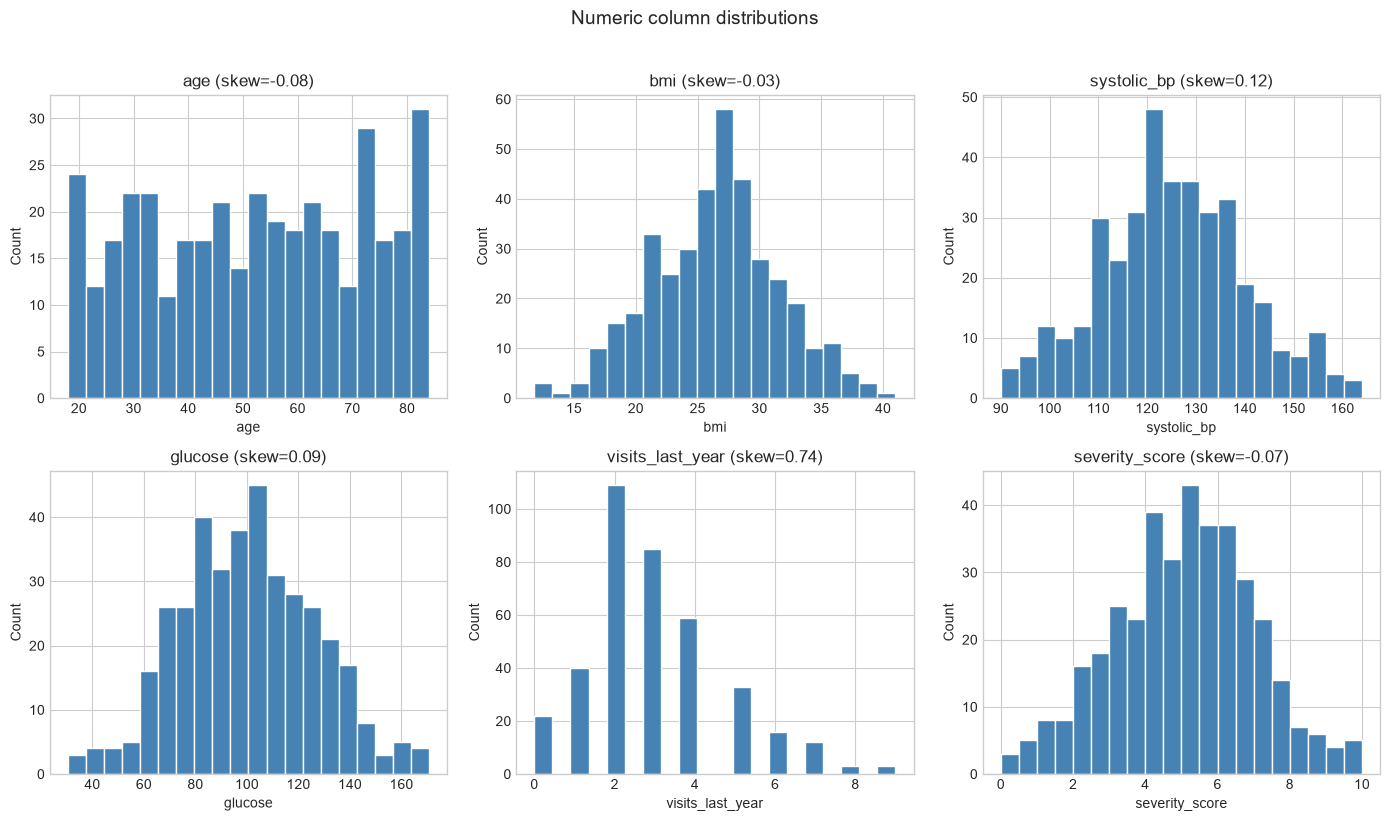

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    data = df[col].dropna()
    ax.hist(data, bins=20, edgecolor="white", color="steelblue")
    skew = data.skew()
    ax.set_title(f"{col} (skew={skew:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.suptitle("Numeric column distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Univariate — categorical columns

Class balance affects how reliable accuracy-scoring will be when masking a categorical column.

In [4]:
for col in categorical_cols:
    counts = df[col].value_counts()
    props = df[col].value_counts(normalize=True).round(3)
    summary = pd.DataFrame({"count": counts, "proportion": props})
    print(f"\n{col}:")
    display(summary)

    minority_pct = props.min() * 100
    if minority_pct < 25:
        print(f"  → Minority class is {props.idxmin()} at {minority_pct:.1f}% — masking this column needs care.")


gender:


,count,proportion
gender,,
Female,192,0.503
Male,190,0.497



smoking_status:


,count,proportion
smoking_status,,
Never,206,0.539
Former,93,0.243
Current,83,0.217


  → Minority class is Current at 21.7% — masking this column needs care.

region:


,count,proportion
region,,
West,102,0.267
East,96,0.251
South,94,0.246
North,90,0.236


  → Minority class is North at 23.6% — masking this column needs care.


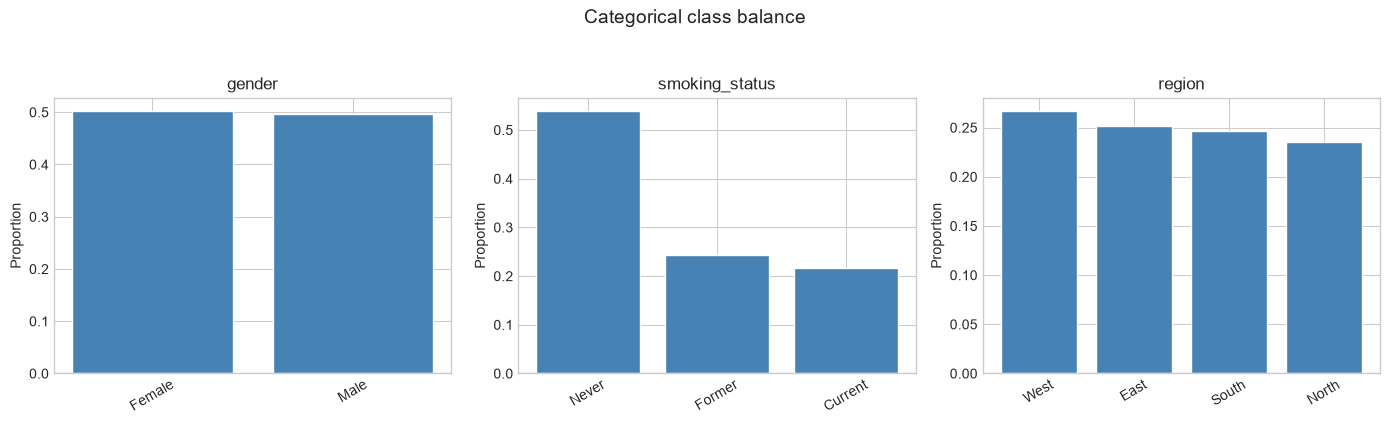

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    props = df[col].value_counts(normalize=True).reindex(order)
    ax.bar(props.index.astype(str), props.values, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Categorical class balance", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 3. Bivariate — numeric × numeric

Correlation matrix — strongest relationships become candidate **MAR driver-column pairs**.

In [6]:
corr = df[numeric_cols].corr().round(3)
display(corr)

pairs = []
for i, col_a in enumerate(numeric_cols):
    for col_b in numeric_cols[i + 1:]:
        r = corr.loc[col_a, col_b]
        pairs.append({"col_a": col_a, "col_b": col_b, "r": r, "abs_r": abs(r)})

top_pairs = pd.DataFrame(pairs).sort_values("abs_r", ascending=False)
print("\nStrongest numeric relationships:")
display(top_pairs.head(5))

,age,bmi,systolic_bp,glucose,visits_last_year,severity_score
age,1.000,-0.138,0.125,-0.041,-0.033,-0.090
bmi,-0.138,1.000,0.012,0.101,-0.068,0.020
systolic_bp,0.125,0.012,1.000,0.011,-0.062,0.022
glucose,-0.041,0.101,0.011,1.000,-0.024,-0.028
visits_last_year,-0.033,-0.068,-0.062,-0.024,1.000,0.017
severity_score,-0.090,0.020,0.022,-0.028,0.017,1.000



Strongest numeric relationships:


,col_a,col_b,r,abs_r
0,age,bmi,-0.138,0.138
1,age,systolic_bp,0.125,0.125
6,bmi,glucose,0.101,0.101
4,age,severity_score,-0.090,0.090
7,bmi,visits_last_year,-0.068,0.068


## 4. Bivariate — numeric × categorical

Group means — useful for masking justification and general dataset understanding.

In [7]:
group_targets = ["glucose", "bmi", "systolic_bp", "severity_score"]

for cat in categorical_cols:
    print(f"\n{'=' * 50}")
    print(f"Grouped by {cat}")
    print('=' * 50)
    grouped = df.groupby(cat, observed=True)[group_targets].agg(["mean", "std", "count"]).round(2)
    display(grouped)


Grouped by gender


glucose                 bmi             systolic_bp               \
          mean    std count   mean   std count        mean    std count   
gender                                                                    
Female   99.44  27.02   192  26.30  4.92   192      126.62  14.94   192   
Male    101.06  25.36   190  26.51  5.31   190      123.49  14.45   190   

       severity_score              
                 mean   std count  
gender                             
Female           5.04  1.91   192  
Male             4.99  1.97   190


Grouped by smoking_status


glucose                 bmi             systolic_bp         \
                  mean    std count   mean   std count        mean    std   
smoking_status                                                              
Current         103.87  26.96    83  26.68  4.93    83      125.73  16.51   
Former           96.09  26.94    93  26.09  5.69    93      125.80  14.10   
Never           100.67  25.40   206  26.44  4.92   206      124.46  14.36   

                     severity_score              
               count           mean   std count  
smoking_status                                   
Current           83           5.02  1.56    83  
Former            93           5.11  1.93    93  
Never            206           4.97  2.08   206


Grouped by region


glucose                 bmi             systolic_bp               \
          mean    std count   mean   std count        mean    std count   
region                                                                    
East    100.50  28.70    96  25.85  5.22    96      126.15  15.10    96   
North   100.39  27.12    90  25.83  5.69    90      127.69  14.54    90   
South    99.19  25.53    94  27.16  5.16    94      122.01  15.16    94   
West    100.87  23.73   102  26.73  4.32   102      124.54  13.93   102   

       severity_score              
                 mean   std count  
region                             
East             4.50  1.84    96  
North            5.05  1.93    90  
South            5.19  1.99    94  
West             5.31  1.90   102

## 5. Visual checks

Boxplots (sanity check post-cleaning) and correlation heatmap (dissertation figure).

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

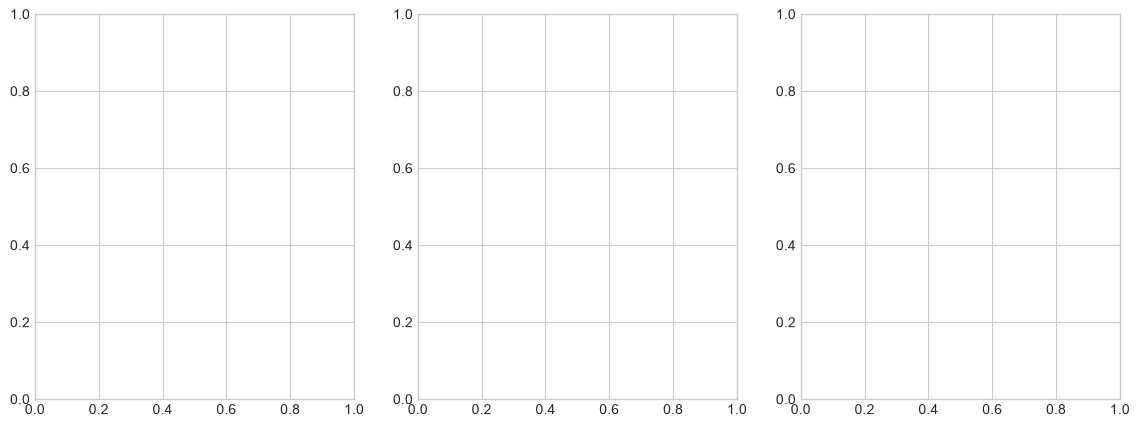

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

box_configs = [
    ("bmi", "gender"),
    ("glucose", "smoking_status"),
    ("systolic_bp", "region"),
]

for ax, (num_col, cat_col) in zip(axes, box_configs):
    groups = [df.loc[df[cat_col] == cat, num_col].dropna().values for cat in df[cat_col].dropna().unique()]
    labels = sorted(df[cat_col].dropna().unique())
    groups = [df.loc[df[cat_col] == cat, num_col].dropna().values for cat in labels]
    ax.boxplot(groups, labels=labels)
    ax.set_title(f"{num_col} by {cat_col}")
    ax.set_ylabel(num_col)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Boxplots — post-cleaning sanity check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation heatmap — numeric columns")
plt.tight_layout()
plt.show()

## 6. Findings summary

Masking recommendations for the missing-data pipeline — saved alongside the cleaning log.

In [ ]:
top3 = top_pairs.head(3)
best_pair = top_pairs.iloc[0]

best_numeric_mask = variance_summary.sort_values("cv_pct", ascending=False).index[0]
worst_numeric_mask = variance_summary.sort_values("cv_pct", ascending=True).index[0]

cat_balance = {col: df[col].value_counts(normalize=True).round(3).to_dict() for col in categorical_cols}
smoking_minority = df["smoking_status"].value_counts(normalize=True).min() * 100

glucose_by_smoking = df.groupby("smoking_status", observed=True)["glucose"].mean().round(1)
bmi_by_gender = df.groupby("gender", observed=True)["bmi"].mean().round(1)

findings = f"""# EDA Findings — patient_records_clean.csv

Generated from `patient_records_descriptive_eda.ipynb`  
Dataset: {len(df)} rows, {len(df.columns)} columns, 0 missing values

## 1. Numeric columns

- **Best spread (masking candidate):** `{best_numeric_mask}` (CV = {variance_summary.loc[best_numeric_mask, 'cv_pct']}%)
- **Lowest spread:** `{worst_numeric_mask}` (CV = {variance_summary.loc[worst_numeric_mask, 'cv_pct']}%) — still above near-constant threshold
- **Near-constant columns:** none flagged (all CV > {LOW_CV_THRESHOLD}%)
- **Distribution notes:**
  - `age` — fairly uniform across 18–84 (skew ≈ {df['age'].skew():.2f})
  - `glucose` — right-skewed with a wide range (skew ≈ {df['glucose'].skew():.2f})
  - `visits_last_year` — discrete count, right-skewed (skew ≈ {df['visits_last_year'].skew():.2f})
  - `severity_score` — roughly symmetric, full 0–10 range used

## 2. Categorical columns

- **gender:** balanced ({cat_balance['gender']})
- **region:** roughly balanced ({cat_balance['region']})
- **smoking_status:** imbalanced — Current smokers are minority at {smoking_minority:.1f}% ({cat_balance['smoking_status']})
  - Masking `smoking_status` is viable but accuracy-scoring for the Current class will be less reliable

## 3. Strongest numeric correlations (MAR driver candidates)

| Pair | r | Interpretation |
|------|---|----------------|
| {top3.iloc[0]['col_a']} ↔ {top3.iloc[0]['col_b']} | {top3.iloc[0]['r']:.3f} | {'Negative: older patients tend to have lower BMI' if top3.iloc[0]['r'] < 0 else 'Positive association'} |
| {top3.iloc[1]['col_a']} ↔ {top3.iloc[1]['col_b']} | {top3.iloc[1]['r']:.3f} | {'Age-related BP increase (clinically plausible)' if 'systolic' in top3.iloc[1]['col_b'] else 'Moderate association'} |
| {top3.iloc[2]['col_a']} ↔ {top3.iloc[2]['col_b']} | {top3.iloc[2]['r']:.3f} | BMI–glucose link (metabolic, clinically plausible) |

## 4. Numeric × categorical differences

- Mean glucose by smoking: {glucose_by_smoking.to_dict()}
- Mean BMI by gender: {bmi_by_gender.to_dict()}
- Glucose differs most across smoking groups (Current highest at {glucose_by_smoking.max():.1f}); gender difference in BMI is negligible

## 5. Masking recommendations

### Numeric column to mask
**`glucose`** — wide range (30.5–170.7), good variance (CV {variance_summary.loc['glucose', 'cv_pct']}%), clinically meaningful, and shows group differences by smoking status.

### Categorical column to mask
**`smoking_status`** — three clear classes with meaningful association to glucose; Current class minority ({smoking_minority:.1f}%) is a known limitation for accuracy scoring.

### MAR driver relationship
**Driver: `age` → Target: `systolic_bp`** (r = {corr.loc['age', 'systolic_bp']:.3f})

- Statistically the strongest *positive* clinically interpretable pair
- Older patients tend toward higher systolic BP — standard cardiovascular epidemiology
- Alternative pair: `bmi` → `glucose` (r = {corr.loc['bmi', 'glucose']:.3f}) for metabolic MAR scenario

## 6. Visual sanity check

- Boxplots show sensible spreads per category with no post-cleaning artefacts
- Correlation heatmap saved in notebook — suitable for dissertation figures
"""

FINDINGS_PATH.write_text(findings, encoding="utf-8")
print(findings)
print(f"\nSaved to {FINDINGS_PATH.resolve()}")